# 윤동주 『쉽게 씌어진 시』 한자 변환, 단어 빈도 분석 및 네트워크 시각화

이 데이터 분석 프로젝트 노트북은 다음 과정을 포함합니다:
1. **한자 -> 한글 자동 변환** (`hanja` 라이브러리 활용)
2. **형태소 분석 및 단어 빈도수 추출 후 CSV 저장** (`KoNLPy`, `pandas` 활용)
3. **주요 단어 막대그래프(Bar Chart) 시각화** (`matplotlib` 활용)
4. **시어 워드클라우드(WordCloud) 시각화** (`wordcloud` 활용)
5. **단어 동시출현 네트워크(Word Co-occurrence Network) 시각화** (`NetworkX` 활용)

## 1. 필요 라이브러리 설치 및 환경 설정
분석에 필요한 주요 파이썬 패키지를 설치하고 한글 폰트를 설정합니다.

In [1]:
!pip install hanja pandas matplotlib wordcloud konlpy networkx

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import os
import re
from collections import Counter
from itertools import combinations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from wordcloud import WordCloud
from konlpy.tag import Okt
import matplotlib.font_manager as fm
import hanja

# 한글 폰트 설정 (NanumGothic)
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(font_path):
    font_name = fm.FontProperties(fname=font_path).get_name()
    plt.rc('font', family=font_name)
    plt.rc('axes', unicode_minus=False)
    print(f'한글 폰트 설정 완료: {font_name}')
else:
    print('기본 폰트를 사용합니다.')

한글 폰트 설정 완료: NanumGothic


## 2. 한자 ↔ 한글 변환 및 결과 파일 저장
원본 `쉽게 씌어진 시.txt` 파일 내 한자를 한글로 변환하여 파일로 저장합니다.

In [3]:
file_path = '쉽게 씌어진 시.txt'

with open(file_path, 'r', encoding='utf-8') as f:
    original_text = f.read()

# 1) 순수 한글 변환 (substitution 모드)
hangul_text = hanja.translate(original_text, 'substitution')

# 2) 한글 병기 변환 (combination-text 모드)
combined_text = hanja.translate(original_text, 'combination-text')

# 텍스트 파일 저장
with open('쉽게 씌어진 시_한글.txt', 'w', encoding='utf-8') as f:
    f.write(hangul_text)

with open('쉽게 씌어진 시_한글병기.txt', 'w', encoding='utf-8') as f:
    f.write(combined_text)

print('✅ 한자 ↔ 한글 변환 및 파일 저장 완료!')

✅ 한자 ↔ 한글 변환 및 파일 저장 완료!


## 3. 형태소 분석 및 단어 빈도수 추출 (CSV 저장)
`KoNLPy`의 `Okt` 형태소 분석기를 활용하여 시어(명사/키워드)를 추출하고, 빈도수를 `단어_빈도수.csv` 파일로 export합니다.

In [4]:
# 복합어 처리 및 텍스트 정제
custom_text = hangul_text.replace('육첩방', '육첩방 ').replace('학비봉투', '학비봉투 ').replace('대학노—트', '대학노트 ')

okt = Okt()
nouns = okt.nouns(custom_text)

# 의미 있는 키워드 추출 (불용어 제거)
stopwords = {'것일가', '어린때', '일이다', '내몰고', '들으려'}
valid_words = []
for word in nouns:
    if len(word) >= 2 and word not in stopwords:
        valid_words.append(word)
    elif word in ['나', '시', '삶']:
        valid_words.append(word)

# 단어 보정
word_map = {'첩방': '육첩방', '씨워진': '씌어진'}
cleaned_words = [word_map.get(w, w) for w in valid_words]

# 빈도 계산
word_counts = Counter(cleaned_words)

# DataFrame 생성 및 CSV 저장
df_words = pd.DataFrame(word_counts.most_common(), columns=['단어', '빈도수'])
df_words.to_csv('단어_빈도수.csv', index=False, encoding='utf-8-sig')

print('=== 주요 단어 빈도수 상위 15개 ===')
print(df_words.head(15))
print('\n✅ 단어_빈도수.csv 파일로 성공적으로 저장되었습니다.')

=== 주요 단어 빈도수 상위 15개 ===
     단어  빈도수
0     나    5
1    창밖    2
2    밤비    2
3   육첩방    2
4    나라    2
5   씌어진    1
6     시    1
7    시인    1
8    천명    1
9    땀내    1
10   사랑    1
11   학비    1
12   봉투    1
13   대학    1
14   노트    1

✅ 단어_빈도수.csv 파일로 성공적으로 저장되었습니다.


## 4. 주요 단어 빈도수 막대그래프 (Bar Chart)
상위 빈도 단어를 수평 막대그래프로 시각화합니다.

findfont: Failed to find font weight bold, now using 600.


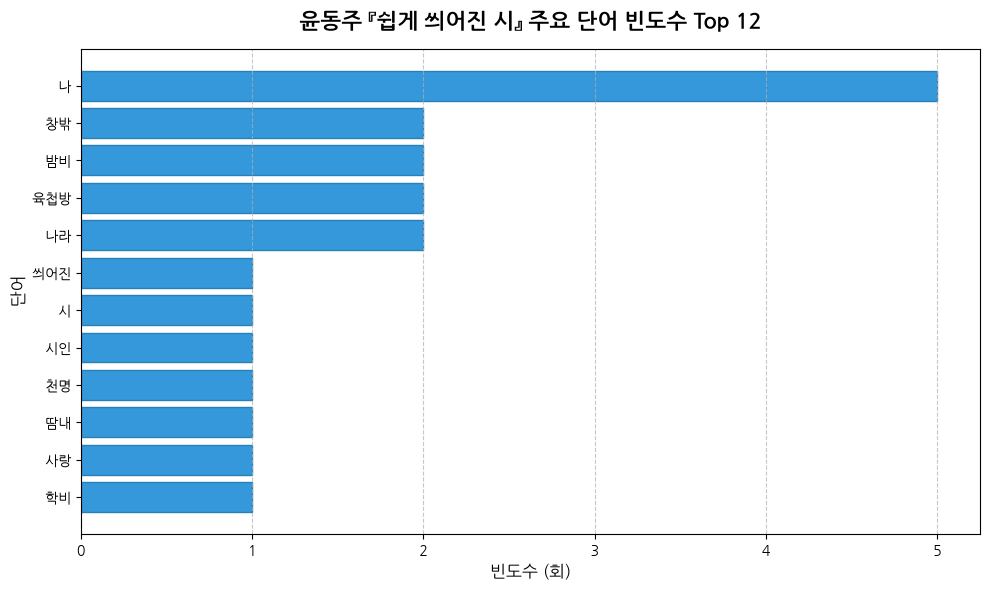

In [5]:
top_words = df_words.head(12)

plt.figure(figsize=(10, 6))
plt.barh(top_words['단어'][::-1], top_words['빈도수'][::-1], color='#3498db', edgecolor='#2980b9')
plt.title('윤동주 『쉽게 씌어진 시』 주요 단어 빈도수 Top 12', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('빈도수 (회)', fontsize=12)
plt.ylabel('단어', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig('bar_chart.png', dpi=300)
plt.show()

## 5. 워드클라우드 (WordCloud) 시각화
시의 주요 단어 가중치를 한눈에 파악할 수 있는 워드클라우드를 생성합니다.

findfont: Failed to find font weight bold, now using 600.


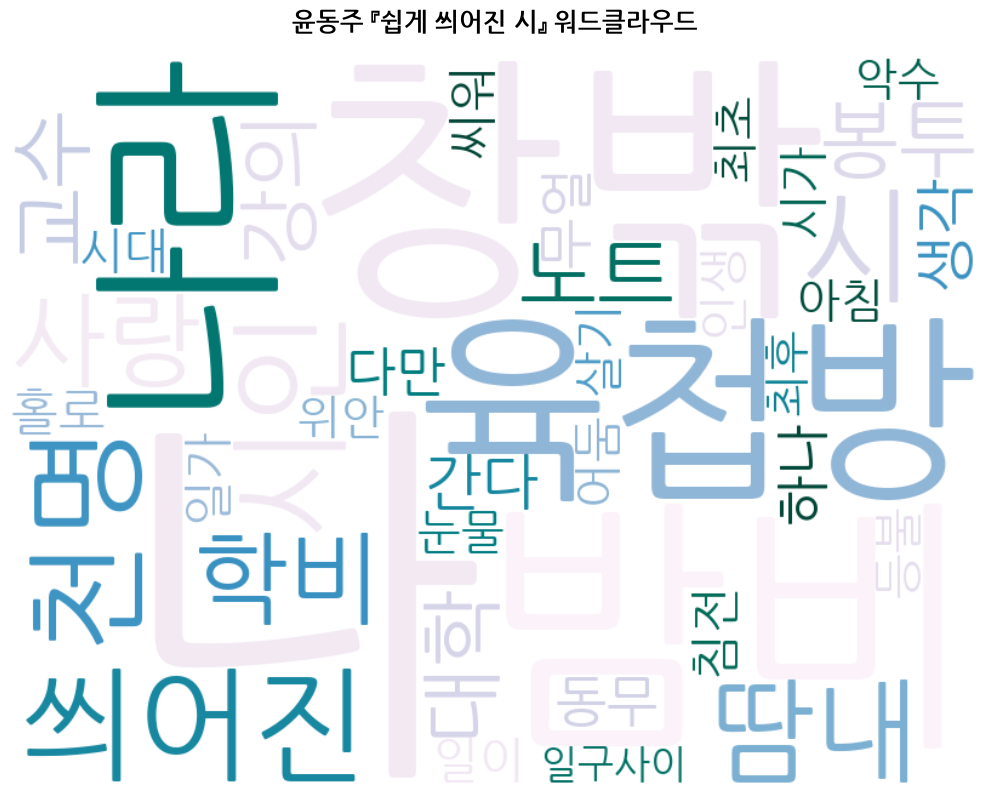

In [6]:
wc = WordCloud(
    font_path=font_path if os.path.exists(font_path) else None,
    background_color='white',
    width=800,
    height=600,
    colormap='PuBuGn',
    random_state=42
)

cloud = wc.generate_from_frequencies(word_counts)

plt.figure(figsize=(10, 8))
plt.imshow(cloud, interpolation='bilinear')
plt.axis('off')
plt.title('윤동주 『쉽게 씌어진 시』 워드클라우드', fontsize=18, pad=20, fontweight='bold')
plt.tight_layout()

plt.savefig('wordcloud.png', dpi=300)
plt.show()

## 6. 단어 동시출현 네트워크 (Word Co-occurrence Network)
연(Strophe) 단위로 함께 등장하는 시어들 간의 연결 관계를 NetworkX 네트워크 그래프로 시각화합니다.

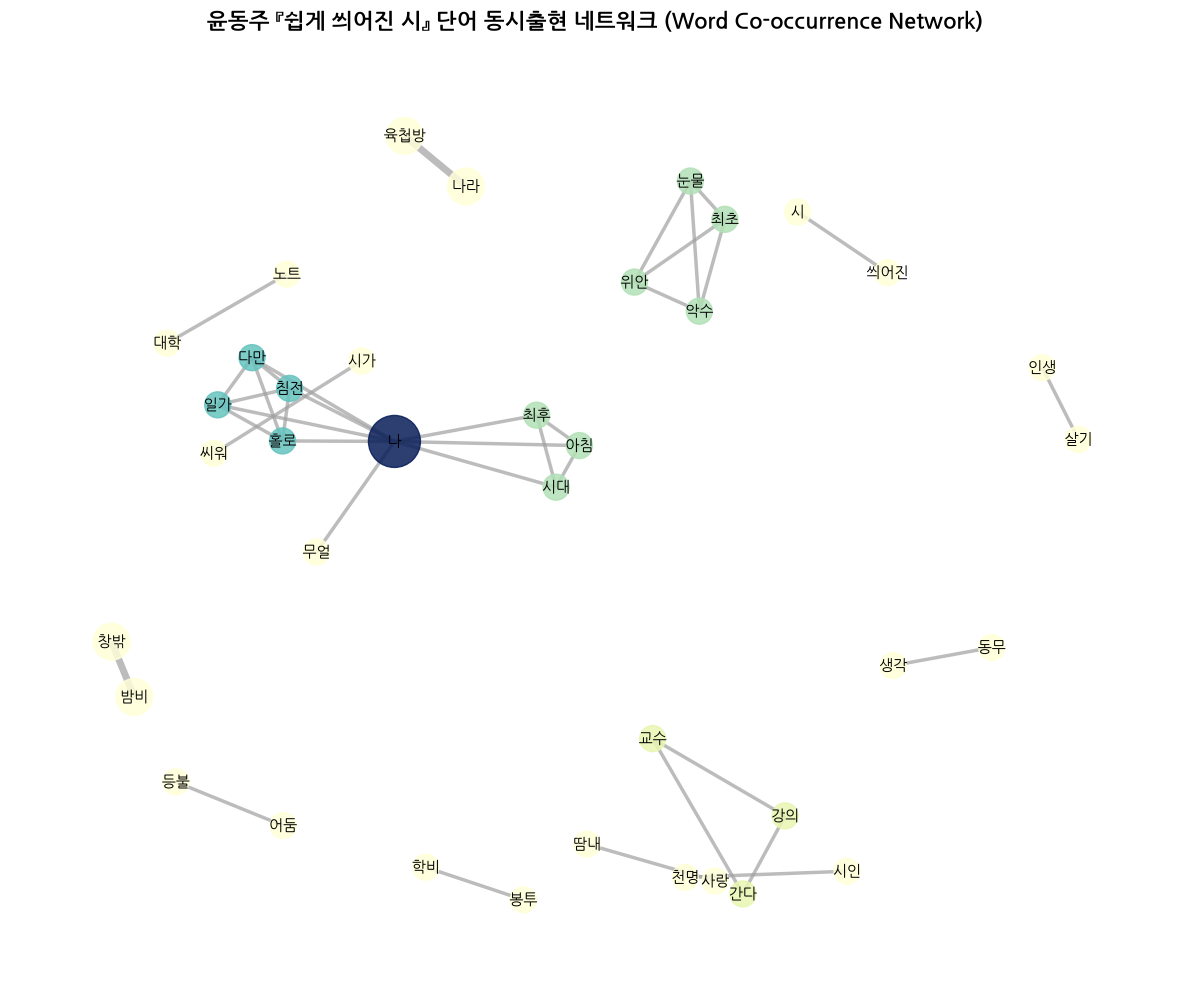

In [7]:
# 1) 연(Strophe) 단위 단어 추출
strophes = [s.strip() for s in hangul_text.split('\n\n') if s.strip()]
strophe_words = []

for strophe in strophes:
    custom_strophe = strophe.replace('육첩방', '육첩방 ').replace('학비봉투', '학비봉투 ').replace('대학노—트', '대학노트 ')
    strophe_nouns = okt.nouns(custom_strophe)
    valid = []
    for w in strophe_nouns:
        if len(w) >= 2 and w not in stopwords:
            valid.append(word_map.get(w, w))
        elif w in ['나', '시', '삶']:
            valid.append(word_map.get(w, w))
    unique_words = list(set(valid))
    if unique_words:
        strophe_words.append(unique_words)

# 2) 동시 출현 빈도 계산
pair_counts = Counter()
for words in strophe_words:
    for p1, p2 in combinations(sorted(words), 2):
        pair_counts[(p1, p2)] += 1

# 3) NetworkX 그래프 구축
G = nx.Graph()
for (node1, node2), weight in pair_counts.items():
    G.add_edge(node1, node2, weight=weight)

# 노드 크기 (단어 전체 빈도 연동)
all_words = [w for words in strophe_words for w in words]
freq_dict = Counter(all_words)
node_sizes = [freq_dict[node] * 350 for node in G.nodes()]

# 연결 중심성에 따른 노드 색상 지정
centrality = nx.degree_centrality(G)
node_colors = [centrality[node] for node in G.nodes()]

# 4) 그래프 시각화
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=0.5, seed=42)

# 엣지 굵기 (동시 출현 빈도 연동)
weights = [G[u][v]['weight'] * 2.5 for u, v in G.edges()]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, cmap=plt.cm.YlGnBu, alpha=0.85)
nx.draw_networkx_edges(G, pos, width=weights, edge_color='#a0a0a0', alpha=0.7)
nx.draw_networkx_labels(G, pos, font_family=font_name, font_size=11)

plt.title('윤동주 『쉽게 씌어진 시』 단어 동시출현 네트워크 (Word Co-occurrence Network)', fontsize=16, pad=20, fontweight='bold')
plt.axis('off')
plt.tight_layout()

plt.savefig('word_network.png', dpi=300)
plt.show()